In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

In [2]:
#Change the working directory
import os
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [3]:
#open the output file

file_path = '/home/apoorva/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/Unified_model/Feedback_T1_PrecursorDriven.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        data_neutral = pkl.load(f)
else:
    raise EOFError("File is empty")

# file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
# with open(file_path, 'rb') as f:
#     SHM_df = pkl.load(f)

/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UnpicklingError: pickle data was truncated

In [ ]:
# open experimental data file 
df = pd.read_csv('data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')
print(df)

df_ont = pd.read_csv('data/New_data/ontogeny_counts.csv')


                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [ ]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0, 70, 140],  labels=['<10 weeks', '>10 weeks'])
print(df)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          41          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [ ]:
# Group the data by agebin and calculate mode and median for 'Age at BMT'
df_mode = df.groupby('agebin')['Age at BMT'].agg([lambda x: x.mode()[0], 'median']).reset_index()
df_mode.columns = ['agebin', 'mode', 'median']
print(df_mode)


      agebin  mode  median
0  <10 weeks    41    41.0
1  >10 weeks    74    80.5


/tmp/ipykernel_408163/2557257773.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mode = df.groupby('agebin')['Age at BMT'].agg([lambda x: x.mode()[0], 'median']).reset_index()


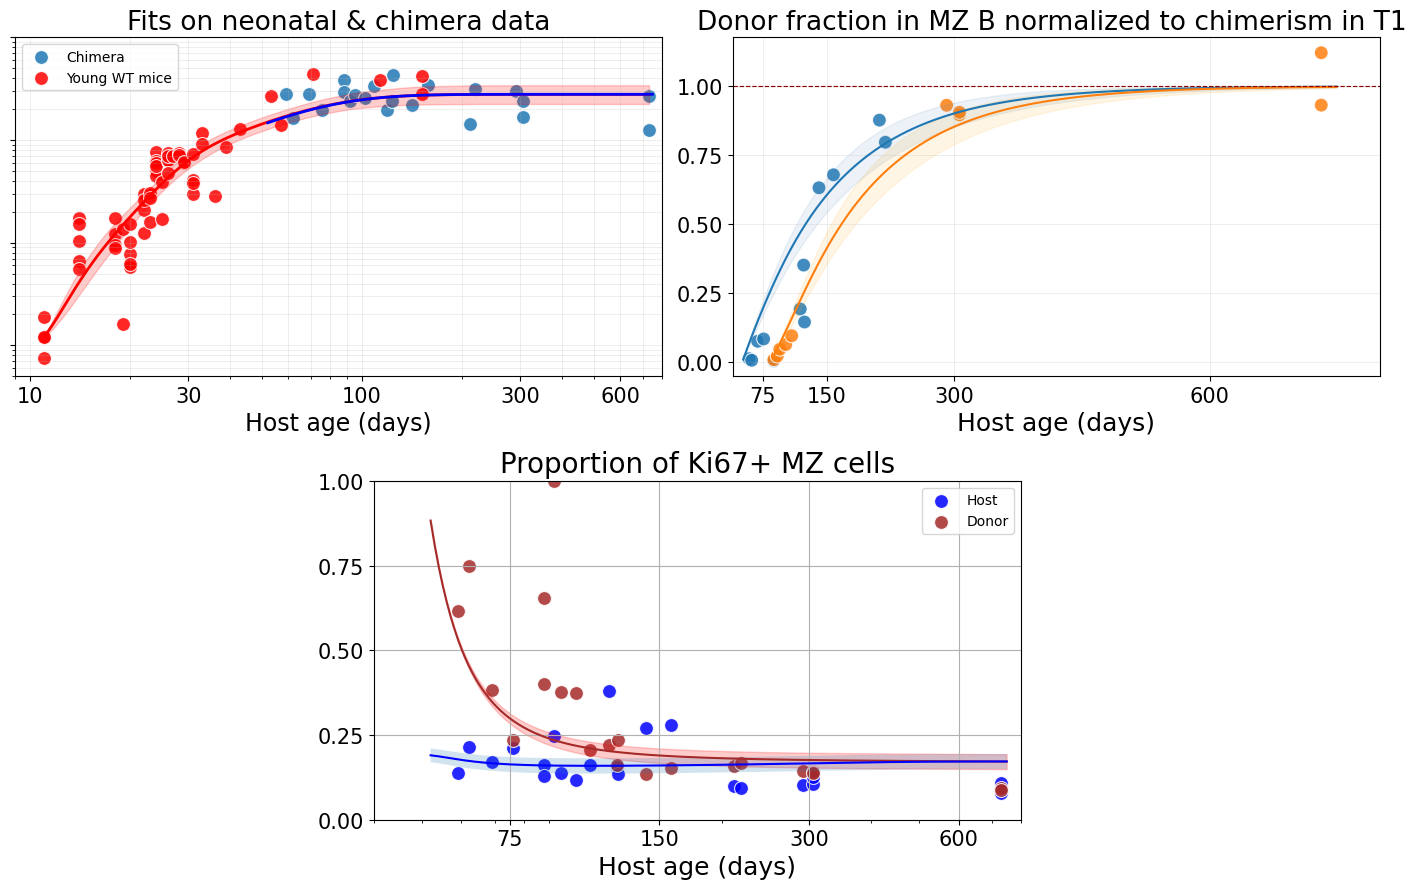

In [ ]:
ts = np.arange(11.1, 732.1, 0.1)
ts1= np.arange(52, 750, 1)
ts2= np.arange(88, 750, 1)


#plot 4*4 grid 

# Create a figure with a custom grid layout
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(2, 4)  # Define a 2x4 grid

# Top row: Two plots
ax1 = fig.add_subplot(gs[0, 0:2])  # First plot spans columns 0 and 1
ax2 = fig.add_subplot(gs[0, 2:4])  # Second plot spans columns 2 and 3

# Bottom row: One centered plot
ax3 = fig.add_subplot(gs[1, 1:3])  # Centered plot spans columns 1 and 2

# Plot the Mz counts
sns.scatterplot(ax=ax1, data=df, x='Age at S1K', y='total_MZ', alpha=0.85, s=100, label='Chimera', legend=False)
sns.scatterplot(ax=ax1, data=df_ont, x='age.at.S1K', y='MZ_total', alpha=0.85, s=100, color='Red', label='Young WT mice', legend=False)
ax1.plot(ts, np.mean(data_neutral.totalMz_pred, axis=0), color='red', linewidth=2)
ax1.plot(ts1, np.mean(data_neutral.MZ_counts_pred1, axis=0), color='blue', linewidth=2)

ax1.fill_between(ts, np.quantile(data_neutral.totalMz_pred, 0.025, axis=0), np.quantile(data_neutral.totalMz_pred, 0.975, axis=0), alpha=0.2, color='red')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5 * 1e3, 1e7)
ax1.set_xlim(9, 800)
ax1.set_xticks([10, 30, 100, 300, 600])
ax1.set_xticklabels([10, 30, 100, 300, 600])
ax1.set_title('Fits on neonatal & chimera data', fontsize=19)
ax1.set_xlabel('Host age (days)', fontsize=17)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.tick_params(axis='both', labelsize=15) 
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax1.legend()

# Plot normalized donor fraction
sns.scatterplot(ax=ax2, data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100, legend=False)
ax2.plot(ts1, np.mean(data_neutral.Nfd_pred1, axis=0))
ax2.plot(ts2, np.mean(data_neutral.Nfd_pred2, axis=0))
ax2.fill_between(ts1, np.quantile(data_neutral.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred1, 0.975, axis=0), alpha=0.1, color= 'steelblue')
ax2.fill_between(ts2, np.quantile(data_neutral.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral.Nfd_pred2, 0.975, axis=0), alpha=0.1, color = 'orange')

# ax2.set_xscale('log')
ax2.set_xlim(40, 800)
ax2.set_xticks([75, 150,  300,  600])
ax2.set_xticklabels([75, 150,  300,  600])
# ax2.set_xscale('log')
#ax2.set_xticks(np.arange(0, 750, 100))
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=18)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=19)
ax2.axhline(y=1, color='darkred', linestyle='dashed', linewidth=0.85)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)      
# ax2.legend(title='Age at BMT', fontsize=12)
#Construct a new dataframe for agebin1, agebin2 and agebin3
# df_Ki67_bin1 = df[df['agebin'] == 'agebin1 = [41,61]']
# df_Ki67_bin2 = df[df['agebin'] == 'agebin2 = [62,81]']    
# df_Ki67_bin3 = df[df['agebin'] == 'agebin3 = [82,101]']
# Plot Proportion of Ki67+ MZ cells
sns.scatterplot(ax=ax3, data=df, x='Age at S1K', y='frac_Ki67+_MZ_host', alpha=0.85, s=100, color='blue')
sns.scatterplot(ax=ax3, data=df, x='Age at S1K', y='frac_Ki67+_MZ_donor', alpha=0.85, s=100, color='brown')
ax3.plot(ts1, np.mean(data_neutral.donor_ki_pred1, axis=0), color= 'brown')
ax3.fill_between(ts1, np.quantile(data_neutral.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.donor_ki_pred1, 0.975, axis=0), color= 'red', alpha=0.2)
ax3.plot(ts1, np.mean(data_neutral.host_ki_pred1, axis=0), color = 'blue')
ax3.fill_between(ts1, np.quantile(data_neutral.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral.host_ki_pred1, 0.975, axis=0), alpha=0.2)
ax3.set_ylim(0, 1)
ax3.set_yticks(np.arange(0, 1.25, 0.25))
ax3.set_xscale('log')
ax3.set_xlim(40, 800)
ax3.set_xticks([75, 150, 300, 600])
ax3.set_xticklabels([75, 150, 300, 600])
ax3.tick_params(axis='both', labelsize=15)  # Set font size for both x and y-axis tick labels
ax3.set_ylabel('')
ax3.set_xlabel('Host age (days)', fontsize=18)
ax3.set_title('Proportion of Ki67+ MZ cells', fontsize=20)
ax3.grid(True, ls="solid")
ax3.legend(labels=['Host', 'Donor'])

plt.tight_layout()

#Save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/new_output/TDM_T1_varyinflux.png', dpi=350, bbox_inches='tight')



In [ ]:
# Calculate elpdf for the model

idata = az.from_cmdstanpy(data_neutral, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Compute Loo CV for models with several Likelihoods 
import xarray as xr

# Concatenate the log_likelihood arrays

a1 = np.array(idata.log_likelihood["log_lik_Mz"])
a2 = np.array(idata.log_likelihood["log_lik_Nfd"])
a3 = np.array(idata.log_likelihood["log_lik_Kid"])
a4 = np.array(idata.log_likelihood["log_lik_Kih"])

log_lik = np.concatenate((a1, a2, a3, a4), axis=2)

# Convert the concatenated array to an xarray DataArray
idata.log_likelihood["combined_log_lik"] = xr.DataArray(log_lik, dims=["chain", "draw", "log_likelihood_dim"], coords={"chain": np.arange(log_lik.shape[0]), "draw": np.arange(log_lik.shape[1]), "log_likelihood_dim": np.arange(log_lik.shape[2])})

# Compute loo_cv
loo = loo_result1_combined = az.loo(idata, var_name="combined_log_lik")
print(loo)

Computed from 5000 posterior samples and 146 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   -28.98    16.51
p_loo       11.89        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      145   99.3%
   (0.70, 1]   (bad)         1    0.7%
   (1, Inf)   (very bad)    0    0.0%



/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'd'}>,
        <Axes: title={'center': 'phi'}>],
       [<Axes: title={'center': 'phi0'}>, <Axes: title={'center': 'r'}>,
        <Axes: title={'center': 'K'}>]], dtype=object)

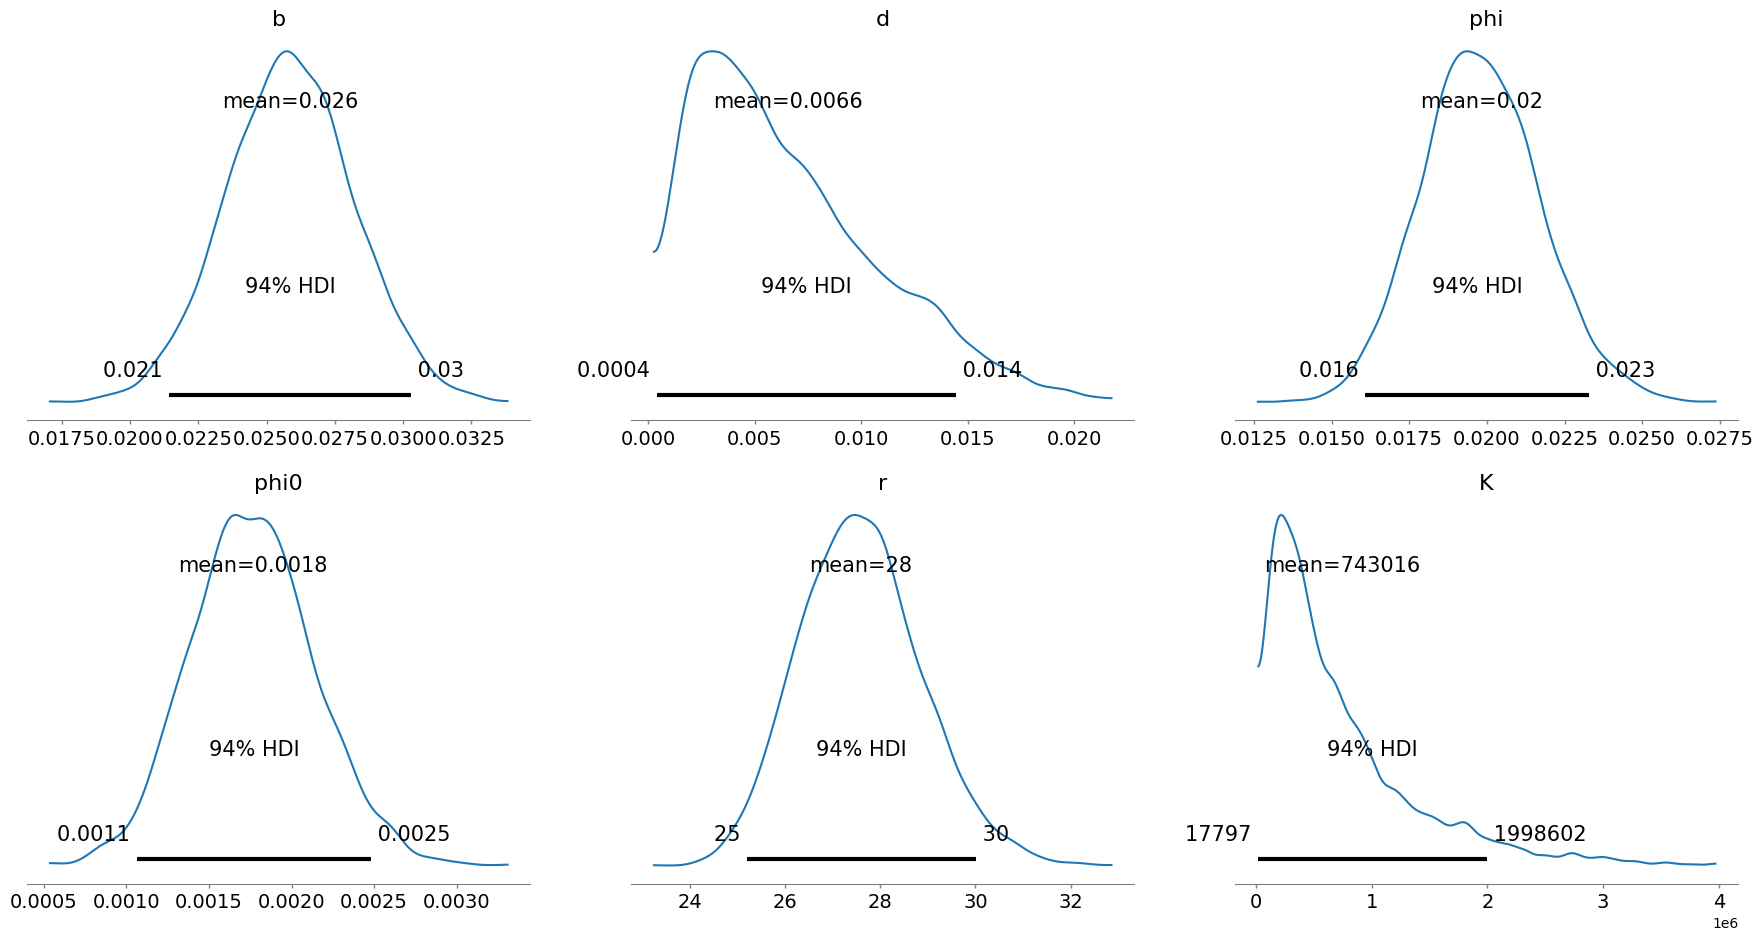

In [ ]:

# print(np.mean(data_neutral.r_d))

az.plot_posterior(data_neutral, var_names=['b','d','phi', 'phi0','r', 'K'], kind='kde')
# az.plot_posterior(data_neutral, var_names=['b', 'd','kappa_0', 'K'], kind='kde')

# print(np.mean(data_neutral.kappa_0))

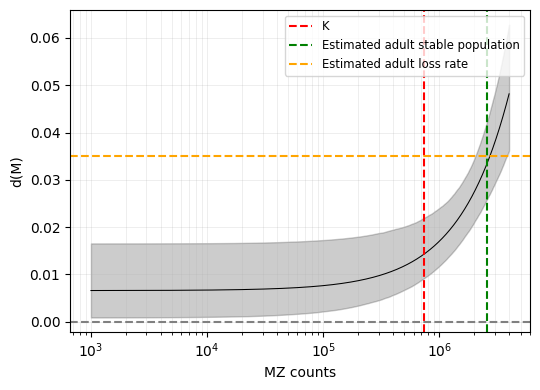

In [ ]:
# Define division rate array 
def d_m(M, d, K):
    return d* (1 + (M / K))

# M = np.arange(0, np.exp(15), 1)
M = np.logspace(3, 6.6, 10000)
d = data_neutral.stan_variable('d')
K = data_neutral.K
# phi = SHM_df.phi
# rho = SHM_df.rho
# M_stable = SHM_df.MZ_counts_pred1
M_stable = data_neutral.MZ_counts_pred1[-1]
# delta = ((phi * 1308516) / M_stable[:,0] ) + rho

# Compute d_m for all posterior samples
M_broadcast = M[:, np.newaxis]  # Shape: (len(M), 1)
d_m_samples = d_m(M_broadcast, d, K)  # Shape: (len(M), n_samples)

# Calculate statistics
d_m_mean = np.mean(d_m_samples, axis=1)
d_m_lower = np.percentile(d_m_samples, 2.5, axis=1)
d_m_upper = np.percentile(d_m_samples, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4))
axes.plot(M, d_m_mean, color='black', linewidth=0.75)
axes.fill_between(M, d_m_lower, d_m_upper, alpha=0.2, color='black')

plt.axvline(x=np.mean(K), color='red', linestyle='--', label='K')
plt.axvline(x=np.mean(M_stable), color='green', linestyle='--', label='Estimated adult stable population')
plt.axhline(y=0.035, color='orange', linestyle='--', label='Estimated adult loss rate')
plt.axhline(y=0, color='grey', linestyle='--')
axes.set_ylabel('d(M)')
axes.set_xlabel('MZ counts')
axes.set_xscale('log')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

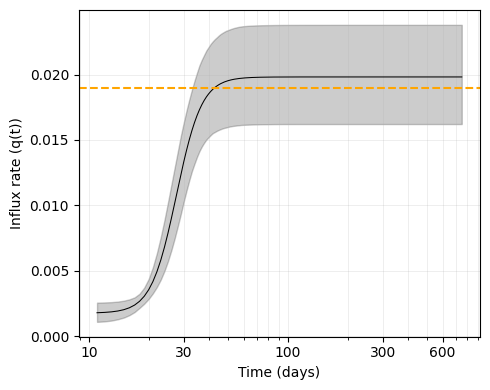

In [ ]:
def q(t, phi , phi0, r):
    return ((phi-phi0)/ (1 + (r/ t)**7)) + phi0

# def phi(t):
#     phi_0 = 0.017
#     return phi_0 / ((34**6/ t**6) + 1) + 0.002

t_ev = np.arange(11, 750, 1)
phi_samples = data_neutral.stan_variable('phi')
phi0_samples = data_neutral.stan_variable('phi0')
r_samples = data_neutral.stan_variable('r')
S_samples = np.array([q(t_ev, phi_samples[i], phi0_samples[i], r_samples[i]) for i in range(len(phi_samples))])
S_mean = np.mean(S_samples, axis=0)
S_lower = np.percentile(S_samples, 2.5, axis=0)
S_upper = np.percentile(S_samples, 97.5, axis=0)
# phi_adult = SHM_df.phi

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(t_ev, S_mean, color='black', linewidth=0.75)
ax.fill_between(t_ev, S_lower, S_upper, alpha=0.2, color='black')
# plt.plot(t_ev, phi(t_ev), color='red', linewidth=0.5)
plt.axhline(y=0.019, color='orange', linestyle='--', label='Estimated adult influx rate')
# plt.axhspan(np.quantile(SHM_df.phi, 0.025), np.quantile(SHM_df.phi, 0.975), color='orange', alpha=0.15)
ax.set_xscale('log')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Influx rate (q(t))')
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()  


[[ 2633.48119743  3058.07687935  3730.07628684 ...  4435.55188603
   4579.20821504  4467.5210667 ]
 [ 4785.70314772  5519.39421725  6651.26719593 ...  7854.65639426
   8104.9001241   7892.15167891]
 [ 7199.27343378  8219.16950673  9722.46675019 ... 11357.18487554
  11709.51929103 11367.77705521]
 ...
 [22446.69806523 29239.33649907 24596.31352838 ... 21552.05240265
  22128.42589793 27830.62601649]
 [22446.69806524 29239.33649908 24596.31352839 ... 21552.05240266
  22128.42589795 27830.62601652]
 [22446.69806525 29239.3364991  24596.31352841 ... 21552.05240268
  22128.42589796 27830.62601655]]


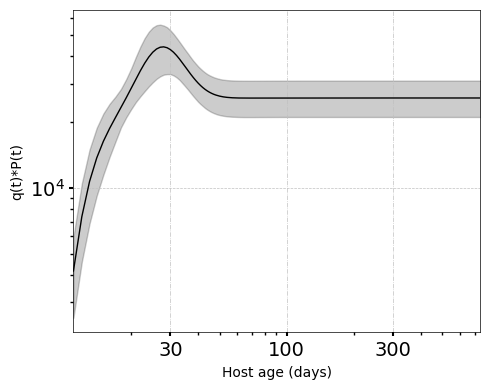

In [ ]:
# Plot q(t)*P(t)
def P(t):
    theta_0 = 14.08
    nu = 0.25
    n = 1.8
    return np.exp(theta_0) * (1 + (t-10)**n * np.exp(-nu * (t-10)))

def P1(t):
    theta_0 = 14.1
    nu = 0.31
    n = 2
    return np.exp(theta_0) * (1 + (t-10)**n * np.exp(-nu * (t-10)))

plt.figure(figsize=(5, 4))
phi_P = np.zeros((len(t_ev), len(phi_samples)))
for i in range(len(phi_samples)):
    phi_P[:, i] = q(t_ev, phi_samples[i], phi0_samples[i], r_samples[i])*P(t_ev)    
    
print(phi_P)
phi_P_median = np.mean(phi_P, axis=1)
phi_P_lower = np.quantile(phi_P, 0.025, axis=1)
phi_P_upper = np.quantile(phi_P, 0.975, axis=1)
plt.plot(t_ev, phi_P_median, color='black', linewidth=1)
# plt.plot(t_ev, phi(t_ev), color='orange', linewidth=0.5)
plt.fill_between(t_ev, phi_P_lower, phi_P_upper, alpha=0.2, color='black')
plt.yscale('log')
plt.xscale('log')
plt.xlim(11, 740)
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
# plt.title('Source term S(t) relative to P(t)')
plt.xlabel('Host age (days)')
plt.ylabel('q(t)*P(t)')
ax = plt.gca()
# Axis border width 
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.tick_params(axis="both", labelsize=14)   
# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
ax.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
ax.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()      
# plt.savefig('figures/Ontogeny_Source_Relative_to_P.pdf', dpi=300)
plt.show()

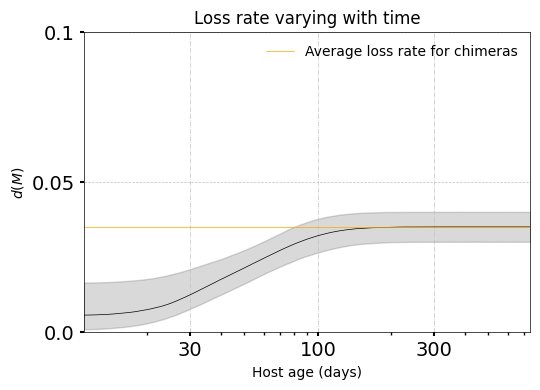

In [ ]:
# Define the birth rate function in terms of t (avoid name clash with variable 'r')
def d_time(d, M, K):
    """Instantaneous logistic birth rate d(M) given parameters."""
    return d * (1.0 +(M / K))

def P(t):
    theta_0 = 14.08
    nu = 0.25
    n = 1.8
    return np.exp(theta_0) * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, phi0, b, d, K, r):
    M_val = y[0]
    dMdt = q(t, phi, phi0, r) * P(t) + b * M_val - d_time(d, M_val, K) * M_val
    # dMdt = S(t,r) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
b = data_neutral.b
d = data_neutral.d
K = data_neutral.K
phi = data_neutral.phi
phi0 = data_neutral.phi0
r = data_neutral.r


# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
# S = lamda * data_neutral.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(b), len(t_ev)))
for i in range(len(b)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=( phi[i], phi0[i], b[i], d[i], K[i], r[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute r(t)
d_t = np.zeros((len(t_ev), len(b)))
for i in range(len(b)):
    M_t = sol[i, :]
    d_t[:, i] = d_time(d[i], M_t, K[i])

# Calculate statistics
d_median = np.median(d_t, axis=1)
d_lower = np.percentile(d_t, 2.5, axis=1)
d_upper = np.percentile(d_t, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(5.5, 4))
axes.plot(t_ev, d_median, color='black', linewidth=0.5)
axes.fill_between(t_ev, d_lower, d_upper, alpha=0.15, color='black')
# plt.axhline(y=0, color='grey', linestyle='--')
# plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
# plt.yscale('log')
plt.axhline(y=0.035, color='orange', label='Average loss rate for chimeras', linewidth=0.5)
# plt.axhspan(np.quantile(delta, 0.025), np.quantile(delta, 0.975), color='orange', alpha=0.15)
# plt.axhline(y=np.median(posterior_df.rho), color='orange', linestyle='--', label='Adult division rate (Ontogeny)')
# plt.axhspan(np.quantile(posterior_df.rho, 0.025), np.quantile(posterior_df.rho, 0.975), color='orange', alpha=0.2)
axes.set_ylim(0, 0.1)
plt.yticks([0.0, 0.05, 0.1], [0.0, 0.05, 0.1])
axes.set_xlim(11, 740)
plt.xscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
axes.set_ylabel('')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.5)   # try 0.6 / 0.8 / 1.0

# Tick mark width
# ax.tick_params(axis='both', which='both', width=0.8)
plt.title('Loss rate varying with time')
axes.set_ylabel(r'$d(M)$')
axes.set_xlabel('Host age (days)')
ax.tick_params(axis="both", labelsize=14)

# tick mark size and thickness
ax.tick_params(axis="both", which="major", length=3, width=1.5)
ax.tick_params(axis="both", which="minor", length=2, width=1)
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
axes.legend(fontsize='10', frameon=False)
#save figure
# plt.savefig('figures/Fig5C_varS.pdf', dpi=300)
plt.show()

AttributeError: Unknown variable name: source
Available variables are d, b, phi, r, phi0, K_Log, sigma, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, K, parms_ont, parms, totalMz_pred, k_hat_pred1, k_hat_pred2, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

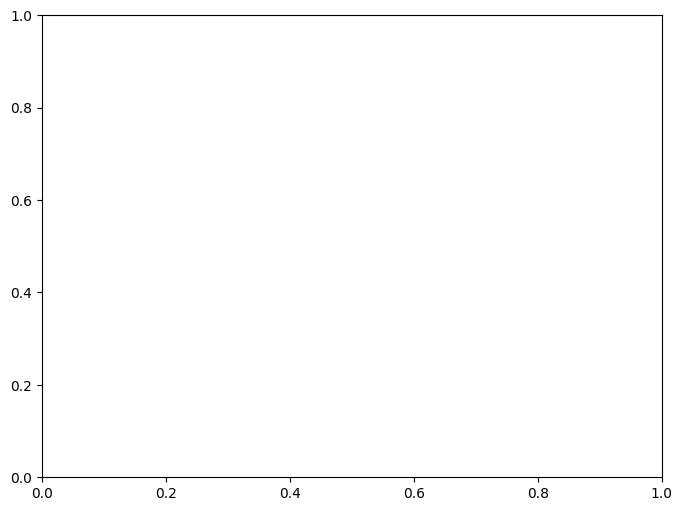

In [ ]:
t_ev = np.arange(11, 750, 1)
fig, ax = plt.subplots(figsize=(8,6))
# ax.plot(t_ev, np.mean(influx_rate_b, axis=0), label='Chimera', color='steelblue')
ax.plot(t_ev, np.mean(data_neutral.source, axis=0), label='Young + Chimera', color='red')
ax.fill_between(t_ev, np.quantile(data_neutral.source, 0.025, axis=0), np.quantile(data_neutral.source, 0.975, axis=0), color='red', alpha=0.2)

# ax.fill_between(t_ev, np.quantile(influx_rate_b, 0.025, axis=0), np.quantile(influx_rate_b, 0.975, axis=0), color='steelblue', alpha=0.2)
# ax.plot(t_ev, (np.mean(data_neutral.P, axis=0)/ np.mean(data_neutral.totalMz_pred, axis=0))*100, label='Young+Chimera', color='red')
# ax.fill_between(t_ev, np.quantile(data_neutral.P, 0.025, axis=0)/ data_neutral.totalMz_pred, np.quantile(data_neutral.P, 0.975, axis=0)/ data_neutral.totalMz_pred, color='red', alpha=0.2)
ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylim(0,1)
# ax.set_yticks([0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15])
# ax.set_yticklabels([0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15])
ax.set_xlim(0, 800)
ax.set_xticks([10, 30, 100, 300, 600])
ax.set_xticklabels([10, 30, 100, 300, 600])
ax.set_xlabel('Host age (days)', fontsize=17)
ax.set_ylabel('')
ax.set_title('Influx of T1 precursors into the MZ B cell pool', fontsize=19)
ax.tick_params(axis='both', labelsize=15)
ax.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax.legend()
plt.tight_layout()


In [ ]:
# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)
    ax.set_ylim(0, 90)
    ax.set_yticks([0, 30, 60, 90])
    ax.set_yticklabels([0, 30, 60, 90], fontsize=15)
    ax.set_xticklabels([])
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))

# Plot rho_inv
plot_with_error_bars(data_neutral.rho_inv, 'rho_inv', 'red', axes[1])


# Plot lamda_inv
plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'red', axes[0])
# plot_with_error_bars(clonallife, 'clonal_half_life', 'red', axes[0])

axes[0].set_ylabel('Days', fontsize=15)
# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('Interdivision time', fontsize=20)
axes[0].set_title('Clonal-half life', fontsize=20)
axes[2].set_title('Residence time', fontsize=20)

# Plot delta_inv
plot_with_error_bars(data_neutral.delta_inv, 'delta_inv', 'red', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 30, 50, 70, 90])
    ax.set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
    ax.set_xticklabels([])
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(5, 6))

# Plot rho_inv
plot_with_error_bars(data_neutral.rho_inv, 'rho_inv', 'red', axes[0])




axes[0].set_ylabel('Days', fontsize=15)
# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[0].set_title('Interdivision time', fontsize=15)
# axes[0].set_title('Clonal-half life', fontsize=20)
axes[1].set_title('Residence time', fontsize=15)

# Plot delta_inv
plot_with_error_bars(data_neutral.delta_inv, 'delta_inv', 'red', axes[1])

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# ts1= np.arange(42, 750, 1)
# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts, np.mean(data_neutral.influx_rate, axis=0))
# axes.fill_between(ts1, np.quantile(data_neutral.influx_rate, 0.025, axis=0), np.quantile(data_neutral.influx_rate, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 0.03)
# axes.set_xlim(0, 730)
# plt.xticks([40, 100, 200, 300, 600], [40, 100, 200, 300, 600])
# axes.set_ylabel('Change in influx')
# axes.set_xlabel('Mouse Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
# #plt.savefig('Interdivision_time.png')
# plt.show()

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot Residual Ki Donor
axes[1, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kid, axis=0), marker='o', color='b')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Host age')
axes[1, 0].set_ylabel('Residual Ki Donor')
axes[1, 0].set_title('Residual Plot: Ki Donor')

# Plot Residual Ki Host
axes[1, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kih, axis=0), marker='o', color='b')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Host age')
axes[1, 1].set_ylabel('Residual Ki Host')
axes[1, 1].set_title('Residual Plot: Ki Host')

# Plot Residual Nfd
axes[0, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Nfd, axis=0), marker='o', color='b')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Host age')
axes[0, 1].set_ylabel('Residual Nfd')
axes[0, 1].set_title('Residual Plot: Nfd')

# Plot Residual Mz Counts
axes[0, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Mz, axis=0), marker='o', color='b')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Host age')
axes[0, 0].set_ylabel('Residual Mz Counts')
axes[0, 0].set_title('Residual Plot: Mz Counts')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Plot Residual Ki Donor
residuals_Kid = np.mean(data_neutral.residuals_Kid, axis=0)

# QQ Plot for Residual Ki Donor
stats.probplot(residuals_Kid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ Plot: Ki Donor')

# Plot Residual Ki Host
residuals_Kih = np.mean(data_neutral.residuals_Kih, axis=0)

# QQ Plot for Residual Ki Host
stats.probplot(residuals_Kih, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot: Ki Host')

# Plot Residual Nfd
residuals_Nfd = np.mean(data_neutral.residuals_Nfd, axis=0)

# QQ Plot for Residual Nfd
stats.probplot(residuals_Nfd, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('QQ Plot: Nfd')

# Plot Residual Mz Counts
residuals_Mz = np.mean(data_neutral.residuals_Mz, axis=0)

# QQ Plot for Residual Mz Counts
stats.probplot(residuals_Mz, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('QQ Plot: Mz Counts')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
netloss = 1/ (data_neutral.delta - data_neutral.rho)
clonallife = np.log(2)*netloss
print(clonallife)
print(np.mean(clonallife))
sns.kdeplot(clonallife)

In [ ]:
# # Define 2D array for influx of shape (10000, 705)

# influx = np.zeros((8000, 705))
# for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# 	influx[:, i] = (data_neutral.phi * 1298783) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i])
 

# # CI for precursor 

# # influx = []
# # for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# # 	influx.append((data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i]))

# # influx = np.array(influx)
# print(len(influx))
# print(influx.shape)
# print(np.quantile(influx, 0.025, axis=0))
# print(np.quantile(influx, 0.975, axis=0))

# # Plot precursor influx with 95% CI

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(influx, axis=0))
# axes.fill_between(ts1, np.quantile(influx, 0.025, axis=0), np.quantile(influx, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 1.5)
# axes.set_xlim(0, 730)
# axes.set_xticks([50, 200, 350, 500])
# axes.set_xticklabels([50, 200, 350, 500])
# axes.set_ylabel('Precursor influx')
# axes.set_xlabel('Host Age (days)')
# axes.set_title('Ratio of influx-produced cells to self-renewing cells in the MZ pool')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
# plt.show()


In [ ]:
'''influx_p = np.zeros((8000, 705))
for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
	influx_p[:, i] = (data_neutral.phi * 1298783) / data_neutral.MZ_counts_pred1[:, i]
 

# CI for precursor 

# influx = []
# for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# 	influx.append((data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i]))

# influx = np.array(influx)
print(len(influx_p))
print(influx_p.shape)
print(np.quantile(influx_p, 0.025, axis=0))
print(np.quantile(influx_p, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx_p, axis=0))
axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Proportion of influx of TA44.1 precursor cells into the MZ pool')
plt.tight_layout()
plt.show()'''


In [ ]:
'''print(np.mean(data_neutral.phi*1298783))
print(np.quantile(data_neutral.phi*1298783, 0.025))
print(np.quantile(data_neutral.phi*1298783, 0.975))'''

In [ ]:
# print(np.mean(data_neutral.delta))

'''print(data_neutral.rho.shape)
print(len(data_neutral.MZ_counts_pred1[0]))'''
# print(data_neutral.rho * data_neutral.MZ_counts_pred1)
# print(np.mean(data_neutral.lamda_inv))
# print(np.mean(data_neutral.beta_inv))
# print(np.mean(data_neutral.rho_inv))
# print(data_neutral.rho * data_neutral.MZ_counts_pred1[15])
# Mz_60 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15]
# print(np.mean(Mz_60))
# # print((data_neutral.MZ_counts_pred1[:, 15]))
# #calculate credible interval

# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.025))
# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.975))

# print('Credible interval for MZ cells at 60 days:', np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], [0.025, 0.975]))




In [ ]:
'''Mz_350 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305]
print(np.mean(Mz_350))
print((data_neutral.MZ_counts_pred1[:, 305]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.975))'''

In [ ]:
'''Mz_600 = data_neutral.rho * data_neutral.MZ_counts_pred3[:, 555]
print(np.mean(Mz_600))
print((data_neutral.MZ_counts_pred1[:, 555]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.975))'''

In [ ]:
'''netloss = 1/ (data_neutral.delta - data_neutral.rho)
clonallife = np.log(2)*netloss
print(clonallife)
print(np.mean(clonallife))
sns.kdeplot(clonallife)'''


# #plot interdivision time

# fig, axes = plt.subplots(1, 1, figsize=(8, 6))
# axes.plot(ts1, np.mean(data_neutral.rho_inv, axis=0), color='red')
# axes.fill_between(ts1, np.quantile(interdiv, 0.025, axis=0), np.quantile(interdiv, 0.975, axis=0), alpha=0.3)
# axes.set_ylim(0, 100)
# axes.set_xlim(0, 730)
# axes.set_ylabel('Interdivision time (days)')
# axes.set_xlabel('Mouse Age (days)')
# axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
# #plt.savefig('Interdivision_time.png')
# plt.show()

In [ ]:
#Daily influx of precursor cells

print(np.mean(data_neutral.phi*1118208))

# Calculate credible interval

print(np.quantile(data_neutral.phi*1118208, 0.025))
print(np.quantile(data_neutral.phi*1118208, 0.975))

In [ ]:
az.plot_posterior(data_neutral, var_names=['rho_inv'], kind='kde')
# sns.histplot(data_neutral.rho_inv, kde=False, bins=30)
sns.kdeplot(data_neutral.rho_inv, color='Blue')

# calculate confidence interval for rho_inv

print(np.quantile(data_neutral.rho_inv, 0.025))
print(np.quantile(data_neutral.rho_inv, 0.975))


In [ ]:
az.plot_posterior(data_neutral, var_names=['lamda_inv'], kind='kde')
# sns.kdeplot(data_neutral.lamda_inv)

print(np.quantile(data_neutral.lamda_inv, 0.025))
print(np.quantile(data_neutral.lamda_inv, 0.975))

In [ ]:
az.plot_posterior(data_neutral, var_names=['phi'], kind = 'kde')

print(np.quantile(data_neutral.phi, 0.025))
print(np.quantile(data_neutral.phi, 0.975))

In [ ]:
az.plot_posterior(data_neutral, var_names=['delta'], kind = 'kde')

In [ ]:
az.plot_posterior(data_neutral, var_names=['rho'], kind = 'kde')

In [ ]:
# az.plot_posterior(data_neutral, var_names=['y0'], kind = 'kde')

In [ ]:
# az.plot_posterior(data_neutral, var_names=['kappa_0'], kind = 'kde')

In [ ]:
az.plot_posterior(data_neutral, var_names=['delta_inv'], kind='kde')

print(np.quantile(data_neutral.delta_inv, 0.025))
print(np.quantile(data_neutral.delta_inv, 0.975))

In [ ]:
#Plot the posterior distribution of the parameters
az.plot_posterior(data_neutral, var_names=['phi', 'rho_inv', 'delta_inv'], kind='kde')



#Plot prior and posterior distribution of the parameters

# az.plot_posterior(data_neutral, var_names=['phi', 'beta', 'rho_Log', 'delta_Log'], kind='kde')
# az.plot_prior(data_neutral, var_names=['phi', 'beta', 'rho_Log', 'delta_Log'], kind='kde')




In [ ]:
#plot normal distribution with mean 14 and sd 1

from scipy import stats


x = np.linspace(0, 30, 100)
y = stats.norm.pdf(x, 14, 2)
plt.plot(x, y)
plt.show()
